# Solution of a hydrodynamic system using the convolution integral
This notebook demonstrates solving the motion of a hydrodynamic system, calculating power, and evaluating the gradient of the system power with respect to PTO damping.

1. Define or ingest hydrodynamic coefficients
2. Define numerical simulation parameters and wave conditions
3. Define body mass properties, initial conditions, and PTO damping
4. Solve the system and calculate power
5. Gradient of power with respect to PTO damping

In [1]:
# First import all necessary julia packages:
using Unitful
using DimensionfulAngles: radᵃ as rad, θ₀, 𝐀, Dispersion
using LinearAlgebra
using Plots
import Random
# import Statistics as Stats
import ForwardDiff as FD
import WaveSpectra

include("..\\src\\Hydrodynamics.jl")

Main.Hydrodynamics

In [2]:
# Hydrodynamics
hydro = Hydrodynamics.Bemio.read_capytaine("data//rm3.nc")

addedMassUnits = 1.0 .* [repeat([u"kg"], 3, 3) repeat([0u"kg*m"/rad], 3, 3); repeat([0u"kg*m"], 3, 3) repeat([0u"kg*m^2"/rad], 3, 3)]
addedMassCoeff = hydro.am[1:6, 1:6, :] .* addedMassUnits # Dimensions: influenced_dof radiating_dof omega

# Don't define force units with Newtons -- it will end up causing conflicts in the out-of-place ODE solve (OOP is required for Zygote)
radDampingUnits = 1.0 * [repeat([u"kg*m/s^2 / (m/s)"], 3, 3) repeat([u"kg*m/s^2 / (1/s)"/rad], 3, 3); repeat([u"kg*m/s^2 * m / (m/s)"], 3, 3) repeat([u"kg*m/s^2 * m / (1/s)"/rad], 3, 3)]
radDampingCoeff = hydro.rd[1:6, 1:6, :] .* radDampingUnits # Dimensions: influenced_dof radiating_dof omega

khsUnits = 1.0 .* [repeat([u"kg*m/s^2 / m"], 3, 3) repeat([u"kg*m/s^2"/rad], 3, 3); repeat([u"kg*m/s^2 * m / m"], 3, 3) repeat([u"kg*m/s^2 * m"/rad], 3, 3)]
khsCoeff = hydro.khs[1:6, 1:6] .* khsUnits # Dimensions: influenced_dof radiating_dof

exUnits = [repeat([u"kg*m/s^2 / m"], 3, 1); repeat([u"kg*m/s^2 * m / m"], 3, 1)]
exCoeff = hydro.ex[1:6, :, :, :] .* exUnits # Dimensions: influenced_dof wave_dir omega complex

Kᵣ, tᵣ = Hydrodynamics.Bemio.radiation_irf(hydro.rd[1:6, 1:6, :], hydro.w, w_max = 5.0, t_f = 30.0, dt = 0.01)
tᵣ = tᵣ .* u"s"
Kᵣ = Kᵣ .* radDampingUnits .* u"s^-1"
addedMassInf = addedMassCoeff[:,:,end]
# addedMassInf = Hydrodynamics.Bemio.alternate_Ainf(Unitful.ustrip.(Kᵣ), hydro.am, hydro.w, Unitful.ustrip.(tᵣ)) .* addedMassUnits

6×6 Matrix{Quantity{Float64}}:
 62581.9 kg              4.08645e-7 kg   …  -0.0 kg m rad^-1
    -6.27576e-7 kg   61535.7 kg              0.0 kg m rad^-1
     8.77205e-11 kg      1.50686e-11 kg     -0.0 kg m rad^-1
     0.0 kg m           -0.0 kg m           -0.0 kg m^2 rad^-1
     0.0 kg m            0.0 kg m           -0.0 kg m^2 rad^-1
    -0.0 kg m           -0.0 kg m        …   0.0 kg m^2 rad^-1

### Wave conditions and numerical set-up
Define relevant wave using WaveSpectra representations (including significant wave height, energy period, spectra, frequency dimension, etc) and time marching parameters (start, ramp, end times; time step)

In [3]:
# Wave conditions
significant_waveheight = 1.0u"m"
amplitude = significant_waveheight/2
energy_period = 6.0u"s"

omega = hydro.w*rad*u"1/s"
dOmega = omega[2] - omega[1]

frequency = uconvert.(u"s^-1", omega, Dispersion())
dFrequency = uconvert.(u"s^-1", dOmega, Dispersion())

spectrum = WaveSpectra.ParametricSpectra.spectrum_pierson_moskowitz(frequency, significant_waveheight, energy_period)
peak_omega_index = argmax(spectrum)
phase = rand(Random.Xoshiro(0), Float64, size(spectrum)) * 2 * pi * rad

# Time-domain set-up
# dt = 10u"ms" # results in type Rational when combined used in the `collect` call
dt = 1.0e-1u"s"
t0 = 0.0u"s"
tf = energy_period * 10
ts = collect(t0:dt:tf)
nt = length(ts)
ramp_time = 6.0*1u"s"
i_ramp = Int64(ramp_time / dt + 1)

elevation = sum(sqrt.(2*spectrum*dFrequency) .* cos.(omega.*ts' .+ phase), dims=1)

1×601 Matrix{Quantity{Float64, 𝐋, Unitful.FreeUnits{(m,), 𝐋, nothing}}}:
 0.265498 m  0.281374 m  0.2966 m  …  0.141475 m  0.18647 m  0.228464 m

### Define body properties
The required body properties include center of gravity and center of buoyancy, mass, moments and products of inertia, displaced volume, and any initial displacements of the bodies.

PTO damping is lumped with radiation damping when the system of equations is solved, but it is defined as a separate input parameter so that it is a distinct input to power production and can be optimized accordingly.

In [4]:
# Body properties
cg = [0., 0., -3.5]u"m"
m = 725833u"kg"
Ixx = [20907301, 21306090.66, 37085481.11]u"kg*m^2"/rad
Ixy = [1e6, 1e6, 1e5]u"kg*m^2"/rad
I = diagm(Ixx)
I[1, 2:3] = I[2:3, 1] = Ixy[1:2]
I[2, 3] = I[3, 2] = Ixy[3]
body_mass = [diagm(repeat([m], 3)) repeat([0u"kg*m"/rad], 3, 3); repeat([0u"kg*m"], 3, 3) I]

# Coefficients for the form: ẍ + c * ẋ + k * x = 0
dof_names = ["Surge", "Sway", "Heave", "Roll", "Pitch", "Yaw"]
dof = 1:2:5
position_units = [u"m", u"m", u"m", rad, rad, rad]
mass = (body_mass[dof,dof] .+ addedMassInf[dof, dof])
inv_mass_units = 1 ./ Unitful.unit.(mass')
inv_mass = inv(Unitful.ustrip.(mass)) .* inv_mass_units

# Hydrostatics calculations
g = zeros(6) .* position_units / u"s^2"
g[3] = -hydro.g[1] * u"m/s^2"
force_gravity = diag(body_mass) .* g
rho = hydro.rho[1] * u"kg/m^3"
volume = hydro.volume * u"m^3"
force_buoyancy = - rho * g * volume
CGCB = hydro.cb*u"m" - cg
force_buoyancy[4:6] = cross(CGCB, force_buoyancy[1:3])
force_hydrostatic = force_gravity + force_buoyancy

# Initial conditions
x₀ = zeros(size(dof)) .* position_units[dof]
dx₀ = zeros(size(dof)) .* position_units[dof] .* u"1/s"
tspan = [t0, tf]

# PTO damping
pto_damping = diagm(1.0e5 .* ones(size(dof))) .* radDampingUnits[dof,dof]
pto_damping_ul = Unitful.ustrip.(pto_damping)

3×3 Matrix{Float64}:
 100000.0       0.0       0.0
      0.0  100000.0       0.0
      0.0       0.0  100000.0

In [ ]:
Aᵣ, Bᵣ, Cᵣ, Dᵣ, Kₛₛ, R²ₛₛ, orderₛₛ = Hydrodynamics.Bemio.radiation_state_space(Kᵣ[dof, dof, :], tᵣ, 9, 0.95)
nₛₛ = sum(orderₛₛ)
ss₀ = zeros(nₛₛ)

dof: 1 1; order: 4
dof: 1 2; order: 4
dof: 1 3; order: 4
dof: 2 1; order: 6
dof: 2 2; order: 2
dof: 2 3; order: 4
dof: 3 1; order: 2
dof: 3 2; order: 6
dof: 3 3; order: 2


34

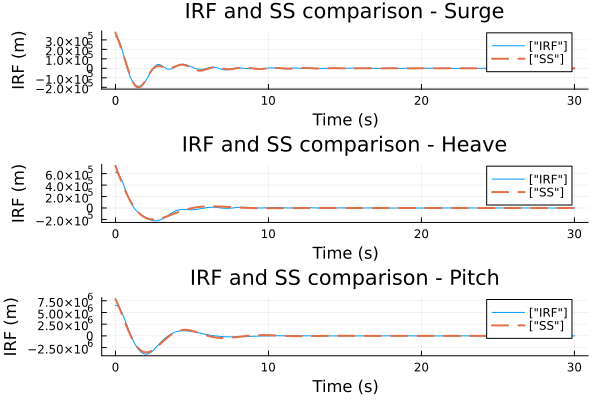

In [7]:
# Visualize SS form
p1 = Plots.plot(tᵣ[1,1,:], Unitful.ustrip.(Kᵣ[dof[1], dof[1],:]), label = ["IRF"])
p1 = Plots.plot!(tᵣ[1,1,:], Kₛₛ[1,1,:], label = ["SS"], title = "IRF and SS comparison - Surge", xaxis="Time", yaxis = "IRF (m)", lw = 2, ls=:dash)
p2 = Plots.plot(tᵣ[1,1,:], Unitful.ustrip.(Kᵣ[dof[2], dof[2],:]), label = ["IRF"])
p2 = Plots.plot!(tᵣ[1,1,:], Kₛₛ[2,2,:], label = ["SS"], title = "IRF and SS comparison - Heave", xaxis="Time", yaxis = "IRF (m)", lw = 2, ls=:dash)
p3 = Plots.plot(tᵣ[1,1,:], Unitful.ustrip.(Kᵣ[dof[3], dof[3],:]), label = ["IRF"])
p3 = Plots.plot!(tᵣ[1,1,:], Kₛₛ[3,3,:], label = ["SS"], title = "IRF and SS comparison - Pitch", xaxis="Time", yaxis = "IRF (m)", lw = 2, ls=:dash)

Plots.plot(p1, p2, p3, layout=(3,1))

### System parameter formatting and energy functions 
All parameters for the system are stored in the tuple `p` to be input to the relevation hydrodynamic and power calculation functions.

In [ ]:
# Unitful and unitless parameter groups
p_unitful = (
    (khsCoeff[dof, dof], 
        radDampingCoeff[dof, dof, peak_omega_index] .* 0,
        inv_mass,
        exCoeff[dof,:,:,:],
        force_hydrostatic[dof],
        (omega, phase, spectrum, dFrequency, t0, ramp_time),
        (Aᵣ, Bᵣ, Cᵣ, Dᵣ, nₛₛ),
    ), [x₀; dx₀; ss₀], tspan, ts, dt, i_ramp)

p_unitless = (
    (Unitful.ustrip.(khsCoeff[dof, dof]),
        Unitful.ustrip.(radDampingCoeff[dof, dof, peak_omega_index].*0),
        Unitful.ustrip.(inv_mass),
        Unitful.ustrip.(exCoeff[dof,:,:,:]),
        Unitful.ustrip.(force_hydrostatic[dof]),
        Unitful.ustrip.((omega, phase, spectrum, dFrequency, t0, ramp_time)),
        (Aᵣ, Bᵣ, Cᵣ, Dᵣ, nₛₛ),
    ),
    Unitful.ustrip.([x₀; dx₀; ss₀]),
    Unitful.ustrip.(tspan),
    Unitful.ustrip.(ts),
    Unitful.ustrip.(dt),
    Unitful.ustrip.(i_ramp)
    )

(([0.0 0.0 0.0; 0.0 2.8009728217349667e6 1.1152678780490533e-9; 0.0 1.1152678780490533e-9 7.206113481356028e7], [0.0 -0.0 0.0; -0.0 0.0 -0.0; 0.0 -0.0 0.0], [1.2683677774844085e-6 1.0783267921268098e-21 -0.0; -5.655317474796333e-23 5.082890062841699e-7 -0.0; 0.0 0.0 4.693493592784703e-8], [2.0311041737386404e-8; 2.8001482923547793e6; 2.1285016593708406e-7;;; 5.179072573469057e-6; 2.797665062134365e6; 5.425501727529536e-5;;; 0.00013186801719200503; 2.793499390076672e6; 0.0013805005377349744;;; … ;;; 2961.423416463907; 609.279939604098; -116.27806247850049;;; -2730.4245875278366; 568.9036671246315; -1950.879191356708;;; -8358.99855510351; 555.4191684153839; -3663.187884503496;;;; -375.2554181510859; -0.3394843812692425; -3932.7180457749105;;; -1500.7369278289316; -5.411167118690884; -15721.822910428762;;; -3375.588449860431; -27.22483262514926; -35340.19594658676;;; … ;;; -10259.617906112284; -407.8930066804164; -7589.046475713282;;; -11101.64379574027; -304.62587088642647; -7150.0502458

## Solve and visualize the system response
Solve the system for the given inputs and visualize its response.

In [10]:
# Solve the hydrodynamic system
diff_eq_solution = Hydrodynamics.hydrodynamic_solver(dx₀, x₀, ts, 
    (khsCoeff[dof, dof], 
        radDampingCoeff[dof, dof, peak_omega_index] .* 0 .+ pto_damping,
        inv_mass,
        exCoeff[dof,:,:,:],
        force_hydrostatic[dof],
        (omega, phase, spectrum, dFrequency, t0, ramp_time)
    )
)

┌ Warning: Using arrays or dicts to store parameters of different types can hurt performance.
│ Consider using tuples instead.
└ @ SciMLBase C:\Users\akeeste\.julia\packages\SciMLBase\O1HPI\src\performance_warnings.jl:32


retcode: Success
Interpolation: 1st order linear
t: 601-element Vector{Quantity{Float64, 𝐓, Unitful.FreeUnits{(s,), 𝐓, nothing}}}:
  0.0 s
  0.1 s
  0.2 s
  0.3 s
  0.4 s
  0.5 s
  0.6 s
  0.7 s
  0.8 s
  0.9 s
  ⋮
 59.2 s
 59.3 s
 59.4 s
 59.5 s
 59.6 s
 59.7 s
 59.8 s
 59.9 s
 60.0 s
u: 601-element Vector{RecursiveArrayTools.ArrayPartition{Quantity{Float64}, Tuple{Vector{Quantity{Float64}}, Vector{Quantity{Float64}}}}}:
 (Quantity{Float64}[0.0 m s^-1, 0.0 m s^-1, 0.0 rad s^-1], Quantity{Float64}[0.0 m, 0.0 m, 0.0 rad])
 (Quantity{Float64}[-4.288307665200446e-6 m s^-1, 1.0769101602135828e-6 m s^-1, -1.103777693002639e-6 rad s^-1], Quantity{Float64}[-1.0987651741826701e-7 m, 2.5193420547536752e-8 m, -2.8275032599438186e-8 rad])
 (Quantity{Float64}[-2.9847682555930403e-5 m s^-1, 1.1333135082057395e-5 m s^-1, -7.681681523910599e-6 rad s^-1], Quantity{Float64}[-1.582434043158816e-6 m, 5.125865825252214e-7 m, -4.0732982180610264e-7 rad])
 (Quantity{Float64}[-8.488830684179758e-5 m s^-1, 4.

In [11]:
# Test the hydrodynamic oscillator with state space function
include("..\\src\\Hydrodynamics.jl")
p = p_unitless
Hydrodynamics.hydrodynamic_oscillator_ss(p[2], p[1], p[5][1]) # u, p, t

40-element Vector{Float64}:
  0.0
  0.0
  0.0
 -0.0001237922714384396
  3.5843843054380635e-5
 -3.183291939029936e-5
  0.0
  0.0
  0.0
  0.0
  ⋮
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0
  0.0

In [12]:
# Solve the hydrodynamic system using the convolution integral
p = p_unitless
diff_eq_solution_ss = Hydrodynamics.hydrodynamic_solver_ss(p[2], p[4], 
    (p[1][1], 
        p[1][2].*0.0 .+ pto_damping_ul, 
        p[1][3], 
        p[1][4], 
        p[1][5],
        p[1][6],
        p[1][7],
        )
)

retcode: Success
Interpolation: 1st order linear
t: 601-element Vector{Float64}:
  0.0
  0.1
  0.2
  0.3
  0.4
  0.5
  0.6
  0.7
  0.8
  0.9
  ⋮
 59.2
 59.3
 59.4
 59.5
 59.6
 59.7
 59.8
 59.9
 60.0
u: 601-element Vector{Vector{Float64}}:
 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
 [-1.099315370655778e-7, 2.5196906549055217e-8, -2.828289212752834e-8, -4.291456029302203e-6, 1.0771202629657243e-6, -1.1042299392537893e-6, 6.74694232830167e-6, 3.608791424798351e-9, -2.329695705940461e-6, -1.856737233952281e-6  …  6.12658780569236e-7, -1.4222572697018325e-5, -9.789659562583575e-13, 2.901609348131617e-14, -8.703452296303097e-14, -2.7366245346307743e-13, -3.4028661468877576e-13, 2.57881665774498e-13, 2.7478194603858896e-7, -7.786840730538457e-6]
 [-1.5853467565884716e-6, 5.12829705639298e-7, -4.0775309918635016e-7, -2.9930828573828902e-5, 1.1340696816098098e-5, -7.693801920885354e-6, 9.540640214284988e-5, 3.6857034772848813e-6, -3.

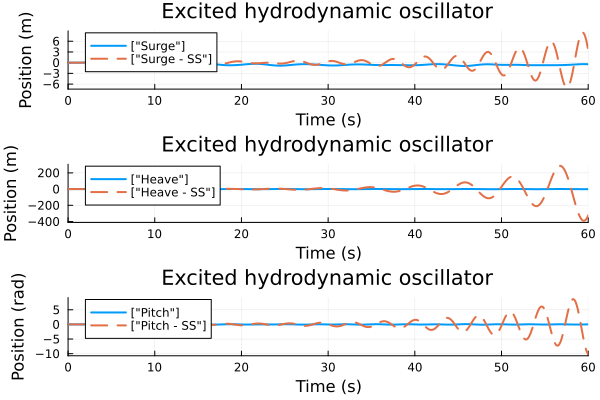

In [13]:
# Visualize response
p1 = Plots.plot(diff_eq_solution, idxs = [4], label = ["Surge"], title = "Excited hydrodynamic oscillator", xaxis="Time", yaxis = "Position", lw = 2)
p1 = Plots.plot!(diff_eq_solution_ss, idxs = [4], label = ["Surge - SS"], title = "Excited hydrodynamic oscillator", xaxis="Time", yaxis = "Position", lw = 2, ls=:dash)
p2 = Plots.plot(diff_eq_solution, idxs = [5], label = ["Heave"], title = "Excited hydrodynamic oscillator", xaxis="Time", yaxis = "Position", lw = 2)
p2 = Plots.plot!(diff_eq_solution_ss, idxs = [5], label = ["Heave - SS"], title = "Excited hydrodynamic oscillator", xaxis="Time", yaxis = "Position", lw = 2, ls=:dash)
p3 = Plots.plot(diff_eq_solution, idxs = [6], label = ["Pitch"], title = "Excited hydrodynamic oscillator", xaxis="Time", yaxis = "Position", lw = 2)
p3 = Plots.plot!(diff_eq_solution_ss, idxs = [6], label = ["Pitch - SS"], title = "Excited hydrodynamic oscillator", xaxis="Time", yaxis = "Position", lw = 2, ls=:dash)

Plots.plot(p1, p2, p3, layout=(3,1))

In [14]:
# Calculation of power and loss
function power_performance(pto_damping, p)
    (p2, dx₀, x₀, tspan, ts, dt, i_ramp) = p

    # Unwrap, edit and rewrap `p` to combine pto and radiation damping. 
    # p2[2] .= p2[2] .+ pto_damping # Don't do this - it overwrites the base p value, skewing iterative calls to power_performance
    (k, c, inv_mass, exCoeff, constant_forces, wave, cic) = p2
    c = c .+ pto_damping
    p2 = (k, c, inv_mass, exCoeff, constant_forces, wave, cic)
    
    diff_eq_solution = Hydrodynamics.hydrodynamic_solver_ss(dx₀, x₀, ts, p2)

    # only absorb power in heave
    heave_ind = findall(x->x==3, Vector(dof))[1]
    heave_damping = pto_damping[heave_ind, heave_ind]
    heave_vel = diff_eq_solution[heave_ind,:]
    power = heave_vel .^ 2 .* heave_damping
    energy = sum(power[i_ramp:end]) * dt
    return energy
end

function power_performance(pto_damping)
    power_performance(pto_damping, p)
end

function power_loss(pto_damping, p)
    # Note p /must/ be passed into power_performance. 
    # If not passed, power_performance uses the global 'p' instead of the 'p' redefined within this function call
    - power_performance(pto_damping, p)
end

function power_loss(pto_damping)
    - power_performance(pto_damping)
end

power_loss (generic function with 2 methods)

In [15]:
### Calculate energy
p = p_unitless
energy_ul = power_performance(pto_damping_ul)
loss_ul = power_loss(pto_damping_ul, p_unitless)
[energy_ul loss_ul]
# [energy loss; energy_ul loss_ul]

BoundsError: BoundsError: attempt to access Tuple{Tuple{Matrix{Float64}, Matrix{Float64}, Matrix{Float64}, Array{Float64, 4}, Vector{Float64}, Tuple{Base.ReinterpretArray{Float64, 1, Quantity{Float64, 𝐀 𝐓^-1, Unitful.FreeUnits{(rad, s^-1), 𝐀 𝐓^-1, nothing}}, Vector{Quantity{Float64, 𝐀 𝐓^-1, Unitful.FreeUnits{(rad, s^-1), 𝐀 𝐓^-1, nothing}}}, false}, Base.ReinterpretArray{Float64, 1, Quantity{Float64, 𝐀, Unitful.FreeUnits{(rad,), 𝐀, nothing}}, Vector{Quantity{Float64, 𝐀, Unitful.FreeUnits{(rad,), 𝐀, nothing}}}, false}, WaveSpectra.OmnidirectionalSpectrum{Float64, Quantity{Float64, 𝐓^-1, Unitful.FreeUnits{(s^-1,), 𝐓^-1, nothing}}}, Float64, Float64, Float64}, Tuple{Matrix{Float64}, Matrix{Float64}, Matrix{Float64}, Matrix{Float64}, Int64}}, Vector{Float64}, Vector{Float64}, Vector{Float64}, Float64, Int64} at index [7]

In [16]:
### Calculate gradient of energy with respect to PTO damping
p = p_unitless

# PTO_damping is not a scalar input here so there is no derivative call.
# derivative_fd = FD.derivative(power_performance, pto_damping_ul[1])

# Use gradient for multiple dofs. Also works with a single dof if pto_damping is a 1x1 array
gradient_fd = FD.gradient(power_performance, pto_damping_ul)
gradient_loss_fd = FD.gradient(power_loss, pto_damping_ul)

BoundsError: BoundsError: attempt to access Tuple{Tuple{Matrix{Float64}, Matrix{Float64}, Matrix{Float64}, Array{Float64, 4}, Vector{Float64}, Tuple{Base.ReinterpretArray{Float64, 1, Quantity{Float64, 𝐀 𝐓^-1, Unitful.FreeUnits{(rad, s^-1), 𝐀 𝐓^-1, nothing}}, Vector{Quantity{Float64, 𝐀 𝐓^-1, Unitful.FreeUnits{(rad, s^-1), 𝐀 𝐓^-1, nothing}}}, false}, Base.ReinterpretArray{Float64, 1, Quantity{Float64, 𝐀, Unitful.FreeUnits{(rad,), 𝐀, nothing}}, Vector{Quantity{Float64, 𝐀, Unitful.FreeUnits{(rad,), 𝐀, nothing}}}, false}, WaveSpectra.OmnidirectionalSpectrum{Float64, Quantity{Float64, 𝐓^-1, Unitful.FreeUnits{(s^-1,), 𝐓^-1, nothing}}}, Float64, Float64, Float64}, Tuple{Matrix{Float64}, Matrix{Float64}, Matrix{Float64}, Matrix{Float64}, Int64}}, Vector{Float64}, Vector{Float64}, Vector{Float64}, Float64, Int64} at index [7]